# Testing the Qiskit Environment

This notebook verifies that your Qiskit installation is working correctly by running two quantum circuit tests on the Aer simulator:

1. **Test Case 1: Bell State (2-qubit entanglement)** — Creates an entangled Bell state and measures the correlation.
2. **Test Case 2: GHZ State (3-qubit entanglement)** — Creates a 3-qubit Greenberger-Horne-Zeilinger state.

Both tests follow the modern Qiskit Runtime workflow using named registers, PUBs (Primitive Unified Blocs), samplers, and post-processing of shot data into counts.

In [3]:
# Import Qiskit and verify installation
import time
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.visualization import plot_histogram
import qiskit

print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.5.2


## Test Case 1: Bell State (2-qubit Entanglement)

The Bell state is a maximally entangled two-qubit state of the form (|00⟩ + |11⟩)/√2. When measured, results should split ~50/50 between '00' and '11'.

In [ ]:
def build_bell_circuit() -> QuantumCircuit:
    """Build a Bell state quantum circuit with named registers.

    Constructs a two-qubit circuit that creates an entangled Bell state
    (|00⟩ + |11⟩)/√2 and measures both qubits.

    Returns
    -------
    QuantumCircuit
        A named Bell state circuit with 2 qubits and 2 classical bits.
    """
    qubits = QuantumRegister(2, name="q")
    bits = ClassicalRegister(2, name="meas")
    circuit = QuantumCircuit(qubits, bits, name="bell_state")

    circuit.h(qubits[0])
    circuit.cx(qubits[0], qubits[1])
    circuit.measure(qubits, bits)

    return circuit

bell_circuit = build_bell_circuit()
print("Bell State Circuit:")
print(bell_circuit.draw(output="text"))

Bell State Circuit:
        ┌───┐     ┌─┐   
   q_0: ┤ H ├──■──┤M├───
        └───┘┌─┴─┐└╥┘┌─┐
   q_1: ─────┤ X ├─╫─┤M├
             └───┘ ║ └╥┘
meas: 2/═══════════╩══╩═
                   0  1 


In [14]:
def run_circuit_on_aer(circuit: QuantumCircuit, shots: int = 10000) -> dict:
    """Run a quantum circuit on the Aer simulator.

    Parameters
    ----------
    circuit : QuantumCircuit
        The quantum circuit to simulate.
    shots : int
        Number of shots (repetitions) for sampling (default: 10000).

    Returns
    -------
    dict
        Dictionary mapping bitstrings to their measurement counts.
    """
    print(f"\nRunning on Aer simulator ({shots} shots)...")
    start_time = time.perf_counter()

    pub = (circuit,)
    sampler = AerSampler()
    job = sampler.run([pub], shots=shots)
    result = job.result()

    pub_result = result[0]
    counts = pub_result.data.meas.get_counts()

    elapsed = time.perf_counter() - start_time
    print(f"Job completed in {elapsed:.2f}s")
    print(f"Counts: {counts}")

    return counts



Running on Aer simulator (10000 shots)...
Job completed in 0.08s
Counts: {'11': 5002, '00': 4998}


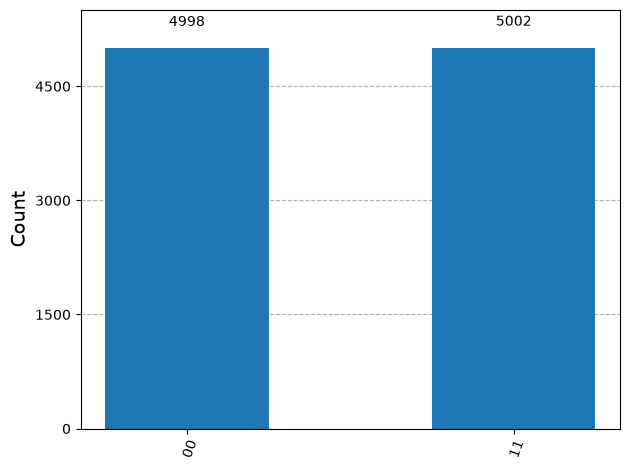

In [15]:

bell_counts = run_circuit_on_aer(bell_circuit, shots=10000)
plot_histogram(bell_counts)

## Test Case 2: GHZ State (3-qubit Entanglement)

The GHZ state is a three-qubit entangled state of the form (|000⟩ + |111⟩)/√2. When measured, results should split ~50/50 between '000' and '111'.

In [16]:
def build_ghz_circuit() -> QuantumCircuit:
    """Build a GHZ state quantum circuit with named registers.

    Constructs a three-qubit circuit that creates a GHZ state
    (|000⟩ + |111⟩)/√2 and measures all three qubits.

    Returns
    -------
    QuantumCircuit
        A named GHZ state circuit with 3 qubits and 3 classical bits.
    """
    qubits = QuantumRegister(3, name="q")
    bits = ClassicalRegister(3, name="meas")
    circuit = QuantumCircuit(qubits, bits, name="ghz_state")

    circuit.h(qubits[0])
    circuit.cx(qubits[0], qubits[1])
    circuit.cx(qubits[1], qubits[2])
    circuit.measure(qubits, bits)

    return circuit

ghz_circuit = build_ghz_circuit()
print("GHZ State Circuit:")
print(ghz_circuit.draw(output="text"))

GHZ State Circuit:
        ┌───┐          ┌─┐      
   q_0: ┤ H ├──■───────┤M├──────
        └───┘┌─┴─┐     └╥┘┌─┐   
   q_1: ─────┤ X ├──■───╫─┤M├───
             └───┘┌─┴─┐ ║ └╥┘┌─┐
   q_2: ──────────┤ X ├─╫──╫─┤M├
                  └───┘ ║  ║ └╥┘
meas: 3/════════════════╩══╩══╩═
                        0  1  2 



Running on Aer simulator (10000 shots)...
Job completed in 0.06s
Counts: {'000': 4948, '111': 5052}


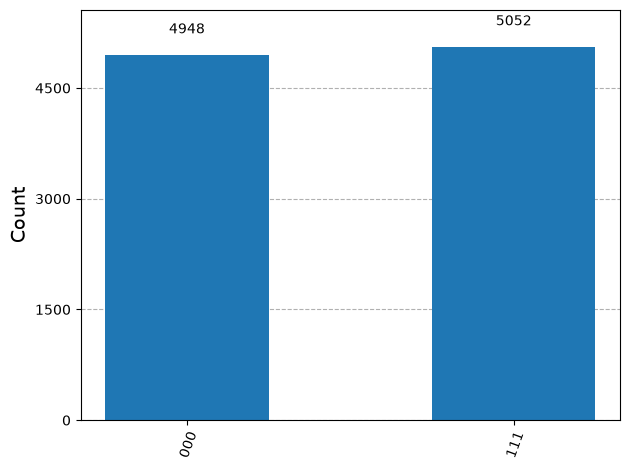

In [17]:
ghz_counts = run_circuit_on_aer(ghz_circuit, shots=10000)
plot_histogram(ghz_counts)

## Running on Real IBM Hardware (ibm_rensselaer)

Now we'll run the same two circuits on `ibm_rensselaer` and compare the results to the ideal simulator output above. What differences do you notice?

This will print status updates as it waits, since there may be other jobs in the queue.

In [18]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as RuntimeSampler

from _job_state import DEFAULT_POLL_INTERVAL, extract_counts, wait_for_job

BACKEND_NAME = "ibm_rensselaer"
ACCOUNT_NAME = "default"

service = QiskitRuntimeService(name=ACCOUNT_NAME)
backend = service.backend(BACKEND_NAME)
print(f"Connected to {backend.name} ({backend.num_qubits} qubits)")

Connected to ibm_rensselaer (120 qubits)


In [19]:
def run_circuit_on_hardware(circuit: QuantumCircuit, backend, shots: int = 10000) -> dict:
    """Run a quantum circuit on real IBM hardware via Qiskit Runtime.

    Transpiles the circuit for the target backend's basis gates and qubit
    connectivity, submits it, and polls until the job finishes.

    Parameters
    ----------
    circuit : QuantumCircuit
        The quantum circuit to run.
    backend
        The IBM backend to run on (from QiskitRuntimeService.backend()).
    shots : int
        Number of shots (repetitions) for sampling (default: 1000).

    Returns
    -------
    dict
        Dictionary mapping bitstrings to their measurement counts.
    """
    print(f"\nRunning on {backend.name} ({shots} shots)...")
    start_time = time.perf_counter()

    pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pass_manager.run(circuit)

    pub = (isa_circuit,)
    sampler = RuntimeSampler(mode=backend)
    job = sampler.run([pub], shots=shots)
    print(
        f"Submitted job {job.job_id()}. Waiting for results "
        f"(checking every {DEFAULT_POLL_INTERVAL}s)..."
    )

    result = wait_for_job(job, backend, poll_interval=DEFAULT_POLL_INTERVAL)
    pub_result = result[0]
    _, counts = extract_counts(pub_result)

    elapsed = time.perf_counter() - start_time
    print(f"Job completed in {elapsed:.2f}s")
    print(f"Counts: {counts}")

    return counts


Running on ibm_rensselaer (10000 shots)...
Submitted job dab96vb4clkc73filia0. Waiting for results (checking every 20s)...
  status: QUEUED -- 1 job(s) pending on ibm_rensselaer
  status: DONE
Job completed in 22.13s
Counts: {'11': 4878, '00': 5004, '01': 56, '10': 62}


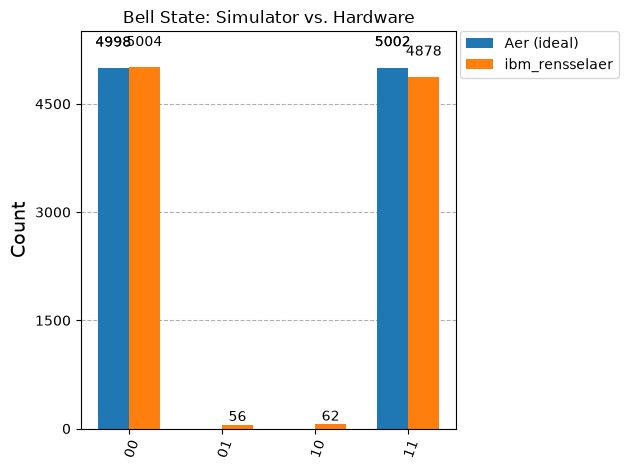

In [20]:
bell_hw_counts = run_circuit_on_hardware(bell_circuit, backend, shots=10000)
plot_histogram(
    [bell_counts, bell_hw_counts],
    legend=["Aer (ideal)", backend.name],
    title="Bell State: Simulator vs. Hardware",
)


Running on ibm_rensselaer (10000 shots)...
Submitted job dab9756rrl7c7386i99g. Waiting for results (checking every 20s)...
  status: QUEUED -- 1 job(s) pending on ibm_rensselaer
  status: DONE
Job completed in 22.07s
Counts: {'000': 4839, '111': 4758, '001': 52, '101': 33, '100': 104, '011': 122, '010': 36, '110': 56}


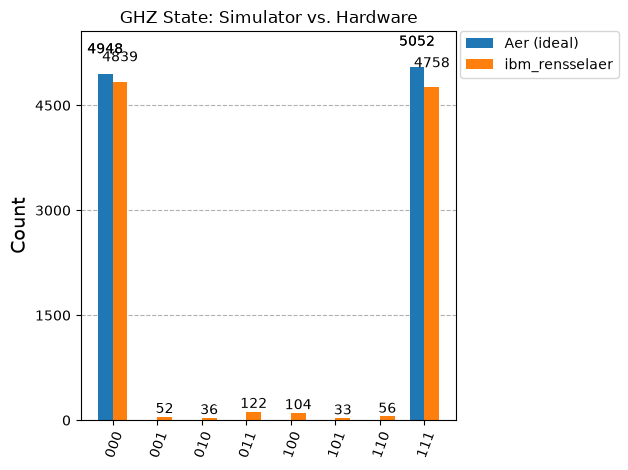

In [21]:
ghz_hw_counts = run_circuit_on_hardware(ghz_circuit, backend, shots=10000)
plot_histogram(
    [ghz_counts, ghz_hw_counts],
    legend=["Aer (ideal)", backend.name],
    title="GHZ State: Simulator vs. Hardware",
)

## Summary

If the Aer results and the hardware results show the same general behavior, your Qiskit environment is properly configured!.